==> Understand the Problem

Given:
Customer data:
- Age
- Gender
- Annual Income
- Spending Score

Goal:
Group customers into similar categories so marketing team can target them

- Is there a target column? == NO
- Do I need prediction? == NO
- Do I need grouping? == YES ✅
- Use CLUSTERING

## Import Libraries & Load the Dataset 

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [33]:
df = pd.read_csv(r"C:\Users\Ankit_\Downloads\Datasets\Mall_Customers.csv")

In [34]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## EDA

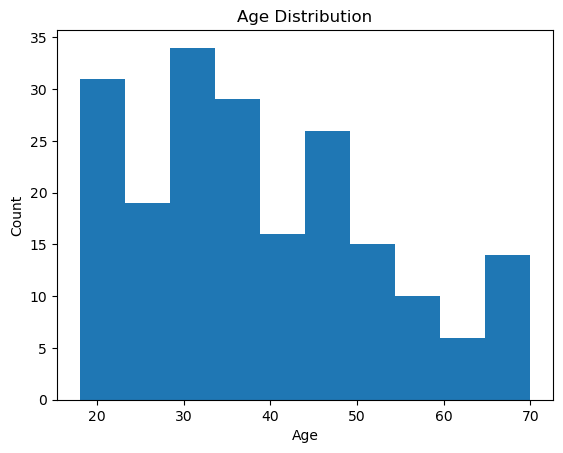

In [36]:
plt.hist(df['Age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Insight: Most customers are between 20–40

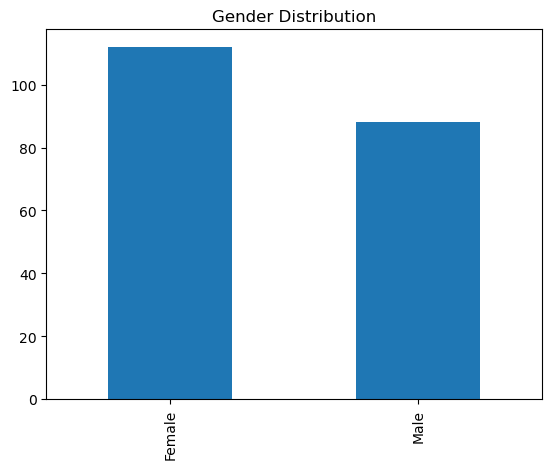

Female    112
Male       88
Name: Gender, dtype: int64


In [37]:
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

print(df['Gender'].value_counts())

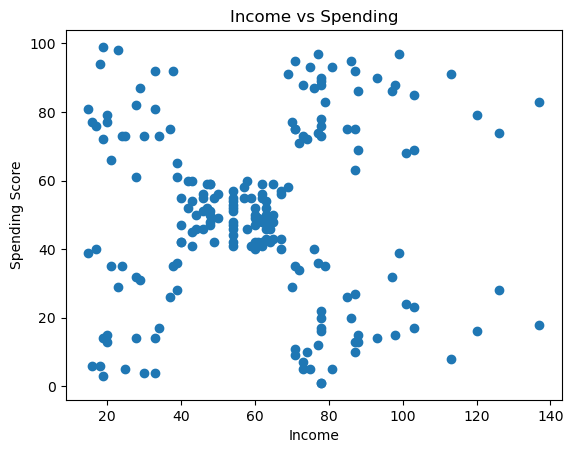

In [38]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending")
plt.show()

You’ll see that natural groups forming

## Select Features 

In [39]:
X = df[['Age','Annual Income (k$)', 'Spending Score (1-100)']]

## Feature Scaling 

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Elbow Method (Find k) 

What are we measuring?

👉 We use WCSS (Within Cluster Sum of Squares)

WCSS=∑∑ ∣∣x−μi∣∣^2

✔️ Meaning:
Distance between each point and its cluster center
Smaller = better clustering

C:\Users\Ankit_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Ankit_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Ankit_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Ankit_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Wi

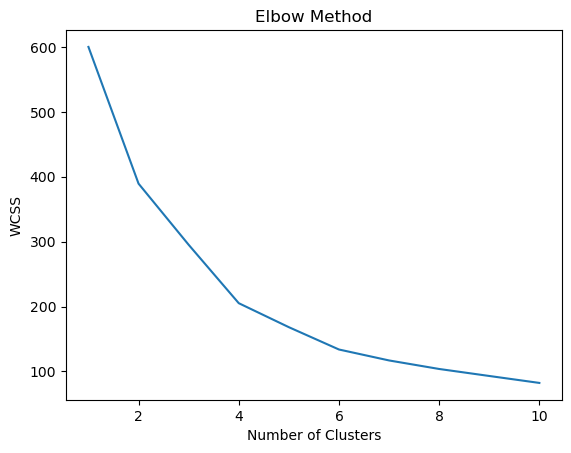

In [41]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

Choose k where graph bends (usually 5)

## Apply KMeans 

In [42]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)   # WHICH CLUSTER

df['Cluster'] = y_kmeans

C:\Users\Ankit_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Visualize Clusters

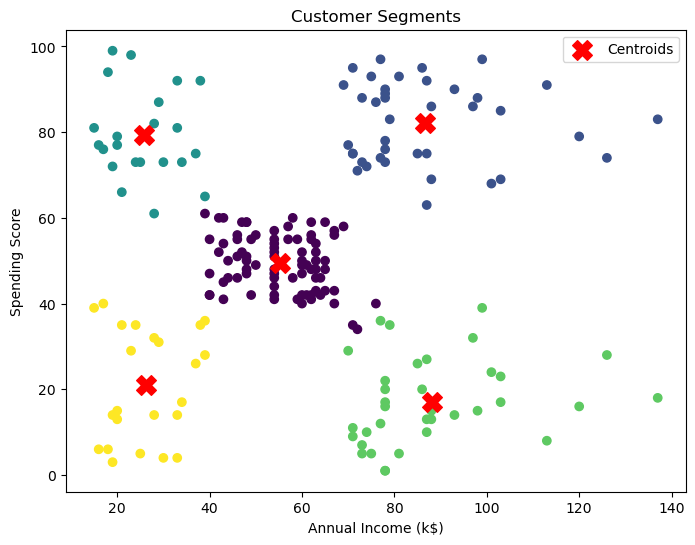

In [50]:
plt.figure(figsize=(8,6))

plt.scatter(df['Annual Income (k$)'], 
            df['Spending Score (1-100)'], 
            c=y_kmeans, cmap='viridis')

centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(centers[:,0], centers[:,1], 
            c='red', s=200, marker='X', label='Centroids')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Segments")

plt.legend()
plt.show()

## Analyze Each Cluster 

In [44]:
print(df.groupby('Cluster').mean())

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         68.775862  55.275862           47.620690               41.706897
1        161.025000  32.875000           86.100000               81.525000
2         23.461538  25.769231           26.115385               74.846154
3         86.377778  26.733333           54.311111               40.911111
4        166.870968  44.387097           89.774194               18.483871


C:\Users\Ankit_\AppData\Local\Temp\ipykernel_16712\2056616278.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  print(df.groupby('Cluster').mean())


Business Insights

Typical output:

- Cluster	Meaning
- 0	Low income, low spending  -- YELLOW
- 1	High income, high spending ⭐ -- BLUE
- 2	Medium   -- PURPLE
- 3	High income, low spending  -- GREEN
- 4	Low income, high spending   -- CYAN




In [47]:
# Shows how many customers in each segment

df.groupby('Cluster').size()

Cluster
0    58
1    40
2    26
3    45
4    31
dtype: int64

##  Target:
## High income + high spending


## Strategy:
## Give offers, premium services 